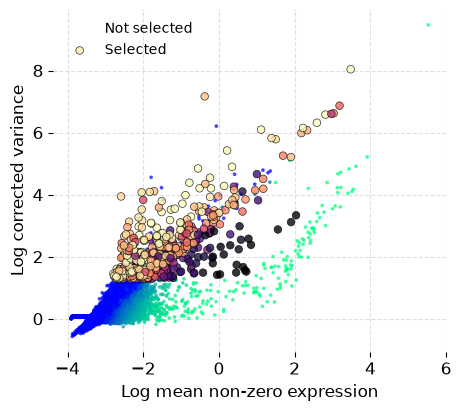

{'matches docs_default': True, 'selected genes': 500}

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
baseline = ds.pipeline.open(label="docs_default")
cell_selection = baseline["analysis_cell_selection"]
hvg_500 = ds.select_hvgs(
    cell_selection,
    top_n=500,
    show_plot=True,
)
hvg_500_values = np.asarray(ds.load_artifact(hvg_500)["values"][:])
{
    "matches docs_default": hvg_500 == baseline["highly_variable_features"],
    "selected genes": int(hvg_500_values.sum()),
}

In [2]:
default_blacklist = (
    "^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|"
    "^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"
)
exclusion_families = {
    "mitochondrial (MT-)": r"^MT-",
    "ribosomal protein (RPS/RPL)": r"^RPS|^RPL",
    "mitoribosomal (MRPS/MRPL)": r"^MRPS|^MRPL",
    "cell cycle (CCN)": r"^CCN",
    "HLA": r"^HLA-",
    "H2": r"^H2-",
    "histone (HIST)": r"^HIST",
    "sex-linked": (
        r"^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$"
        r"|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"
    ),
}
family_counts = pd.Series(
    {
        name: len(ds.RNA.feats.grep(pattern))
        for name, pattern in exclusion_families.items()
    },
    name="genes matching pattern",
)
print(
    "Default blacklist matches:",
    len(ds.RNA.feats.grep(default_blacklist)),
)
family_counts

Default blacklist matches: 329


mitochondrial (MT-)             13
ribosomal protein (RPS/RPL)    104
mitoribosomal (MRPS/MRPL)       80
cell cycle (CCN)                31
HLA                             20
H2                               0
histone (HIST)                  71
sex-linked                      10
Name: genes matching pattern, dtype: int64

In [3]:
hvg_no_blacklist = ds.select_hvgs(
    cell_selection,
    top_n=500,
    blacklist="",
    show_plot=False,
)
selection_values = {
    "hvgs_default": hvg_500_values,
    "hvgs_no_blacklist": np.asarray(
        ds.load_artifact(hvg_no_blacklist)["values"][:]
    ),
}
pd.Series(
    {
        key: int(values.sum())
        for key, values in selection_values.items()
    },
    name="selected genes",
)

hvgs_default         500
hvgs_no_blacklist    500
Name: selected genes, dtype: int64

In [4]:
feature_names = ds.RNA.feats.fetch_all("names")
default_values = selection_values["hvgs_default"]
unblocked_values = selection_values["hvgs_no_blacklist"]
only_without_blacklist = feature_names[unblocked_values & ~default_values]
print("Genes selected only when blacklist is cleared:", len(only_without_blacklist))
pd.Series(only_without_blacklist).head(15)

Genes selected only when blacklist is cleared: 15


0          RPL5
1          RPSA
2     HIST1H2AC
3     HIST1H2BJ
4      HIST1H3H
5       HLA-DRA
6      HLA-DRB1
7      HLA-DQA1
8      HLA-DQB1
9       HLA-DMB
10      HLA-DMA
11     HLA-DPA1
12     HLA-DPB1
13       RPL10A
14         RPS5
dtype: str

In [5]:
feature_1000 = ds.select_hvgs(
    cell_selection,
    top_n=1000,
    show_plot=False,
)
normalized_1000 = ds.run_normalization(cell_selection, feature_1000)
pca_1000 = ds.run_pca(normalized_1000, dims=15)
initialization_1000 = ds.build_embedding_initialization(pca_1000)
ann_1000 = ds.build_ann_index(pca_1000)
neighbors_1000 = ds.query_neighbors(ann_1000, k=11)
graph_1000 = ds.build_connectivity_map(neighbors_1000)
feature_branches = {
    500: (baseline["umap"], baseline["leiden_0.5"]),
    1000: (
        ds.run_umap(graph_1000, initialization_1000),
        ds.run_leiden_clustering(graph_1000, resolution=0.5),
    ),
}

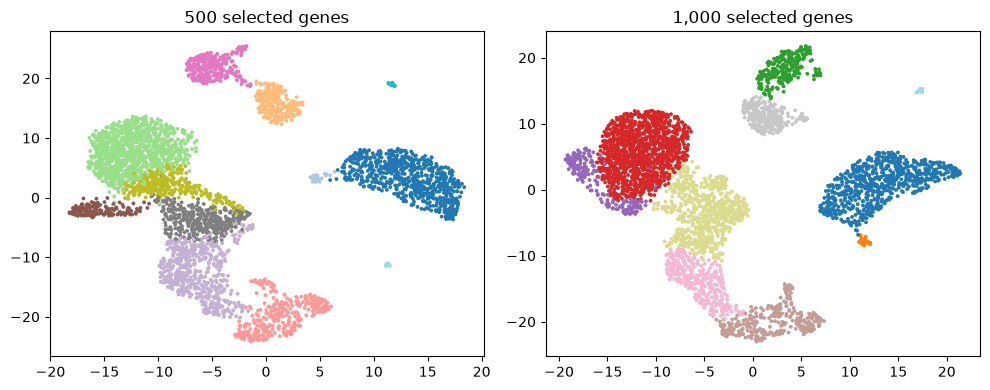

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
cluster_values = {}
for axis, top_n in zip(axes, feature_branches, strict=True):
    umap_ref, cluster_ref = feature_branches[top_n]
    coordinates = np.asarray(ds.load_artifact(umap_ref)["values"][:])
    labels = np.asarray(ds.load_artifact(cluster_ref)["values"][:])
    cluster_values[top_n] = labels
    axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=labels,
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"{top_n:,} selected genes")
figure.tight_layout()
figure

In [7]:
cluster_500 = cluster_values[500]
cluster_1000 = cluster_values[1000]
pd.crosstab(
    pd.Series(cluster_500, name="500 genes"),
    pd.Series(cluster_1000, name="1,000 genes"),
    margins=True,
)

"1,000 genes",1,2,3,4,5,6,7,8,9,10,All
500 genes,,,,,,,,,,,
1,694,0,0,0,0,0,0,0,0,0,694
2,3,25,0,0,0,0,0,0,0,0,28
3,2,0,235,0,0,0,0,0,0,0,237
4,0,0,0,965,9,0,0,0,30,0,1004
5,0,0,0,0,0,311,6,0,0,0,317
6,0,0,0,0,0,7,316,0,216,0,539
7,0,0,0,14,128,0,0,0,0,0,142
8,0,0,12,0,0,0,0,251,0,0,263
9,0,0,0,10,0,0,0,0,368,0,378


In [8]:
pd.Series(
    {
        "adjusted Rand index": adjusted_rand_score(cluster_500, cluster_1000),
        "normalized mutual information": normalized_mutual_info_score(
            cluster_500,
            cluster_1000,
        ),
    },
    name="500 vs 1,000 selected genes",
)

adjusted Rand index              0.749692
normalized mutual information    0.826556
Name: 500 vs 1,000 selected genes, dtype: float64

In [9]:
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
manual_mask = np.isin(
    feature_names.astype(str),
    panel_genes,
)
print("mask length:", len(manual_mask), "selected:", int(manual_mask.sum()))
custom_features = ds.set_feature_selection(mask=manual_mask)
custom_features

mask length: 33538 selected: 6


ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='6a1db608ff3b...')